# Regression Masterclass — Pattern 1: `eqx.tree_at` + raw NumPyro

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/pyrox/blob/main/docs/notebooks/regression_masterclass_treeat.ipynb)

A pedagogical reimplementation of the [Aboleth Regression Master Class](https://aboleth.readthedocs.io/en/stable/tutorials/some_regressors.html) using **Equinox** for deterministic architecture, **NumPyro** for probabilistic semantics, and **einops** for every tensor contraction. Seven Bayesian regression models, all bridged through the same `eqx.tree_at` pattern. **No pyrox abstractions** — this notebook is the canonical raw recipe that the sibling notebooks (`pyrox_sample`, `Parameterized`) progressively collapse.

**What you'll learn:**

1. The three-library architecture: Equinox owns the architecture, NumPyro owns the probability, einops owns the linear algebra.
2. The `eqx.tree_at` bridge — how to inject `numpyro.sample` outputs into a frozen Equinox PyTree.
3. Seven model patterns (linear, MLP, MC-dropout, Bayesian MLP, RFF SVR, hierarchical RFF GP, deep RFF GP), each as a tiny Equinox module + tiny NumPyro model function.
4. Three inference paths from one substrate: NUTS for full Bayesian, SVI+`AutoDelta` for MAP, `Predictive` for posterior-predictive sampling.

## Background — from Bayesian foundations to running code

### Bayesian regression in one diagram

Every model in this notebook is an instance of the same probabilistic structure. We fix:

- a **likelihood** $p(y \mid x, \theta)$ — how observations are generated given parameters,
- a **prior** $p(\theta)$ — what we believed about parameters before seeing data,

and then condition on the observed dataset $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^{N}$ to get the **posterior** via Bayes' rule:

$$p(\theta \mid \mathcal{D}) \;=\; \frac{p(\mathcal{D} \mid \theta)\, p(\theta)}{p(\mathcal{D})} \;=\; \frac{p(\theta) \prod_{i=1}^N p(y_i \mid x_i, \theta)}{\int p(\theta')\, p(\mathcal{D} \mid \theta')\, d\theta'}.$$

The denominator $p(\mathcal{D}) = \int p(\theta) p(\mathcal{D} \mid \theta)\,d\theta$ is the **marginal likelihood** (a.k.a. the *evidence*). It is almost never available in closed form for the models we care about — that intractability is *the* problem that probabilistic programming languages (PPLs) and approximate-inference algorithms exist to solve.

Once we have (an approximation to) the posterior, the quantity we actually want is the **posterior predictive** at a fresh test point $x^*$:

$$p(y^* \mid x^*, \mathcal{D}) \;=\; \int p(y^* \mid x^*, \theta)\, p(\theta \mid \mathcal{D})\, d\theta.$$

This integral is also intractable, but if we have $S$ samples $\theta^{(s)} \sim p(\theta \mid \mathcal{D})$ we can approximate it by Monte Carlo:

$$p(y^* \mid x^*, \mathcal{D}) \;\approx\; \frac{1}{S} \sum_{s=1}^{S} p(y^* \mid x^*, \theta^{(s)}).$$

That last line is *every* `Predictive(model, posterior_samples=...)` call below in one equation.

### From continuous math to a probabilistic program

A PPL is a domain-specific language whose primitives correspond directly to the lines of math above. Translation table:

| Mathematical statement | NumPyro primitive |
|---|---|
| $\theta \sim p(\theta)$ (prior over a latent) | `theta = numpyro.sample("theta", prior_dist)` |
| $y_i \sim p(y \mid x_i, \theta)$ given observed $y_i$ (likelihood) | `numpyro.sample("obs", likelihood_dist(x, theta), obs=y)` |
| $f(\theta) = \texttt{...}$ deterministic function recorded for posterity | `numpyro.deterministic("f", f_of_theta)` |
| A scalar log-prob factor $+\log\phi(\theta)$ that isn't naturally a sample site | `numpyro.factor("phi", log_phi_of_theta)` |

A model is then just a Python function that calls these primitives in some order. Running the function under the right *handler* (NumPyro's word for "interpreter") gives different things:

- **Forward sampling.** `numpyro.handlers.seed(model, rng_seed=0)(...)` runs the function with `obs=None` everywhere and returns one prior-predictive sample.
- **Trace.** `numpyro.handlers.trace(model).get_trace(...)` returns a dict of all sample/deterministic sites with their distributions and values — this is how MCMC and SVI introspect the model.
- **Conditioning.** Passing observed `obs=y` to the likelihood site fixes that draw; the trace's joint log-prob becomes $\log p(\theta) + \log p(y \mid \theta)$ — exactly the un-normalized posterior we want to sample.

**What about the Equinox bit?** `numpyro.sample` returns a JAX array of the right shape. We need that array to flow into the deterministic forward pass `f_\theta(x)`. Equinox modules are immutable PyTrees, so we cannot do `net.weight = w_sampled`. The solution is `eqx.tree_at`:

$$\text{net}_{\text{posterior}} \;=\; \texttt{eqx.tree\_at}\bigl(\lambda m\!:\!m.\text{weight},\, \text{net}_{\text{init}},\, w_{\text{sampled}}\bigr)$$

returns a *new* module identical to the old except at the selected leaf. For multi-leaf injection (an MLP with `W1`, `b1`, `W2`, `b2`), use a tuple selector + tuple of replacements. This is the *only* glue between the deterministic Equinox world and the probabilistic NumPyro world — every pattern below is just a different choice of which leaves to replace.

### From a probabilistic program to a posterior — three solvers

A model function is the input. The output is samples (or a point estimate, or an approximate distribution) of $\theta$. NumPyro ships three solvers, all of which operate on the same model-function interface:

**(1) Markov Chain Monte Carlo via NUTS.** The No-U-Turn Sampler (Hoffman & Gelman, 2014) is an adaptive variant of Hamiltonian Monte Carlo. It builds a Markov chain whose stationary distribution is the exact posterior. Concretely, it computes $\nabla_\theta \log p(\theta, \mathcal{D})$ via reverse-mode autodiff through the model function, simulates Hamiltonian dynamics in $(\theta, p)$-space (where $p$ is an auxiliary momentum), and accepts/rejects via the Metropolis criterion. After a *warmup* phase that adapts step size and mass matrix, the post-warmup draws are (approximately) i.i.d. samples from $p(\theta \mid \mathcal{D})$.

Code: `mcmc = MCMC(NUTS(model_fn), num_warmup=W, num_samples=S); mcmc.run(rng, *args, **kwargs)`. The returned samples are a dict keyed by sample-site name, each value of shape `(S,) + site_shape`.

**(2) Stochastic Variational Inference.** Pick a parametric family $q_\phi(\theta)$ — the *guide* — and solve

$$\phi^* \;=\; \arg\min_\phi \mathrm{KL}\!\bigl(q_\phi(\theta) \,\|\, p(\theta \mid \mathcal{D})\bigr).$$

This minimization is equivalent to maximizing the **Evidence Lower Bound**:

$$\mathcal{L}(\phi) \;=\; \mathbb{E}_{\theta \sim q_\phi}\bigl[\log p(\mathcal{D}, \theta) - \log q_\phi(\theta)\bigr] \;=\; \log p(\mathcal{D}) - \mathrm{KL}\!\bigl(q_\phi \,\|\, p(\cdot \mid \mathcal{D})\bigr) \;\le\; \log p(\mathcal{D}).$$

The ELBO is a tractable Monte Carlo objective: draw $\tilde\theta \sim q_\phi$, compute $\log p(\mathcal{D}, \tilde\theta) - \log q_\phi(\tilde\theta)$, take a stochastic gradient. NumPyro's `SVI(model, guide, optim, Trace_ELBO())` does exactly this. The choice of $q_\phi$ controls expressiveness:

- $q_\phi(\theta) = \delta(\theta - \mu_\phi)$ — a **delta guide**, equivalent to MAP since $\arg\max_\phi \mathcal{L}(\phi) = \arg\max_\theta \log p(\theta, \mathcal{D})$.
- $q_\phi(\theta) = \prod_i \mathcal{N}(\theta_i; \mu_i, \sigma_i^2)$ — a **mean-field normal**, gives an approximate posterior with diagonal covariance.
- Full-rank, normalizing flows, etc.

`numpyro.infer.autoguide.AutoDelta(model_fn)` constructs the delta guide automatically; `AutoNormal(model_fn)` does mean-field normal.

**(3) Posterior predictive sampling.** Once we have either MCMC samples or a fitted guide, getting predictive draws is mechanical:

$$y^{*(s)} \sim p(y \mid x^*, \theta^{(s)}), \qquad \theta^{(s)} \sim p(\theta \mid \mathcal{D}) \text{ (or } q_{\phi^*}\text{)}.$$

`Predictive(model_fn, posterior_samples=samples)(rng, x_test, **kwargs)["obs"]` returns shape `(S, N_test)`. The mean across the $S$ axis is the posterior-predictive mean; the empirical 2.5/97.5 percentiles give a 95% credible interval.

### Helpers? None.

Every helper this notebook would normally need (`make_dataset`, `run_mcmc`, `run_svi`, `predict`, `summarise_predictions`, `compute_r2`) is inlined at the call site. The whole notebook is the codebase.

### The three-library architecture

To keep the model code crisp, three libraries split the work:

- **Equinox** — *deterministic architecture*. `eqx.Module` subclasses with `__call__` methods, immutable PyTrees, the placeholder weights and forward pass.
- **NumPyro** — *probabilistic semantics + inference*. Sample sites, deterministic sites, observed sites, MCMC, SVI, Predictive.
- **einops** — *named-axis tensor algebra*. Every `@` is replaced by `einsum(A, B, "n feat, feat -> n")` so the contracted axis (`feat`) and surviving axis (`n`) are explicit at the call site.

## Setup

Detect Colab and install `pyrox[colab]` (which transitively pulls in `numpyro`, `equinox`, `einops`, `matplotlib`, and `watermark`) only when running there. Local / CI users with the environment already set up skip the install and go straight to imports.

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pyrox[colab] @ git+https://github.com/jejjohnson/pyrox@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from einops import einsum
from numpyro.infer import MCMC, NUTS, SVI, Predictive, Trace_ELBO
from numpyro.infer.autoguide import AutoDelta
from numpyro.optim import Adam


jax.config.update("jax_enable_x64", True)

Print a reproducibility readout so the exact library versions used to generate the committed outputs are unambiguous.

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,equinox,numpyro,einops,matplotlib",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.10.0

jax       : 0.9.2
equinox   : 0.13.6
numpyro   : 0.20.1
einops    : 0.8.2
matplotlib: 3.10.8

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## Toy dataset

A noisy sinc curve, $f(x) = \sin(x) / x$, with 100 training points uniformly drawn in $[-10, 10]$ and a dense test grid in the same range for in-distribution evaluation. The function is nonlinear, oscillatory, and decays toward the boundaries — properties that defeat a straight line and challenge any model with too few hidden units.

In [4]:
key = jr.PRNGKey(666)
k_data, *k_models = jr.split(key, 16)


def latent(x):
    return jnp.sinc(x / jnp.pi)


k1, k2 = jr.split(k_data)
x_train = jr.uniform(k1, (100,), minval=-10.0, maxval=10.0)
y_train = latent(x_train) + 0.05 * jr.normal(k2, (100,))
x_test = jnp.linspace(-10.0, 10.0, 400)
y_test = latent(x_test)


def r2(y_true, y_pred):
    ss_res = jnp.sum((y_true - y_pred) ** 2)
    ss_tot = jnp.sum((y_true - y_true.mean()) ** 2)
    return float(1.0 - ss_res / ss_tot)


def plot_fit(ax, x_train, y_train, x_test, y_test, mean, lo=None, hi=None, title=""):
    ax.plot(x_test, y_test, "k--", lw=1.5, label="True $f(x) = \\sin(x)/x$", zorder=4)
    ax.plot(x_test, mean, "C0-", lw=2, label="Posterior mean", zorder=3)
    if lo is not None and hi is not None:
        ax.fill_between(x_test, lo, hi, color="C0", alpha=0.2, label="95% interval")
    ax.scatter(
        x_train,
        y_train,
        s=20,
        c="C1",
        edgecolors="k",
        linewidths=0.5,
        label="Training data",
        zorder=5,
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.legend(loc="lower center", fontsize=8, ncol=2)


print(f"Training points: {x_train.shape[0]}")
print(f"Test points:     {x_test.shape[0]}")

Training points: 100
Test points:     400


`r2` and `plot_fit` are utility functions to avoid copy-paste across seven model sections — they are scoring and plotting only, not part of any modeling helper layer the notebook would normally pull in. Every `MCMC` / `SVI` / `Predictive` call below is inlined at its call site.

## Model 1 — Bayesian linear regression

A polynomial-feature linear model with a Gaussian prior on the weights. Inference: full posterior via NUTS.

**Generative model.**

$$w \sim \mathcal{N}(0, I_{d+1}), \qquad \sigma \sim \text{HalfNormal}(1)$$

$$\Phi(x)_i = [1, x_i, x_i^2, \dots, x_i^d], \qquad f(x) = \Phi(x)\, w, \qquad y_i \sim \mathcal{N}(f(x_i), \sigma^2)$$

**The bridge.** `weight: jax.Array = jnp.zeros(d+1)` is a placeholder; `numpyro.sample("w", ...)` draws the real weights and `eqx.tree_at(lambda m: m.weight, net, w)` returns a new module with `w` in place of the placeholder.

In [5]:
class LinearRegressor(eqx.Module):
    weight: jax.Array
    degree: int = eqx.field(static=True)

    def __init__(self, degree: int):
        self.degree = degree
        self.weight = jnp.zeros(degree + 1)

    def features(self, x):
        # (N,) -> (N, degree + 1)
        return jnp.stack([x**p for p in range(self.degree + 1)], axis=-1)

    def __call__(self, x):
        # einsum contracts over `feat` (the polynomial-feature axis).
        return einsum(self.features(x), self.weight, "n feat, feat -> n")


def model_linear(x, y=None, *, degree):
    net = LinearRegressor(degree=degree)
    w = numpyro.sample("w", dist.Normal(jnp.zeros(degree + 1), 1.0))
    net = eqx.tree_at(lambda m: m.weight, net, w)
    f = numpyro.deterministic("f", net(x))
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))
    numpyro.sample("obs", dist.Normal(f, sigma), obs=y)

**Inference.** A degree-1 polynomial cannot fit the oscillations of sinc — we expect the line to look terrible and $R^2 \approx 0$. This is the negative control that proves the harness works before we move to expressive models.

Bayesian linear (degree=1) R² = -0.0151


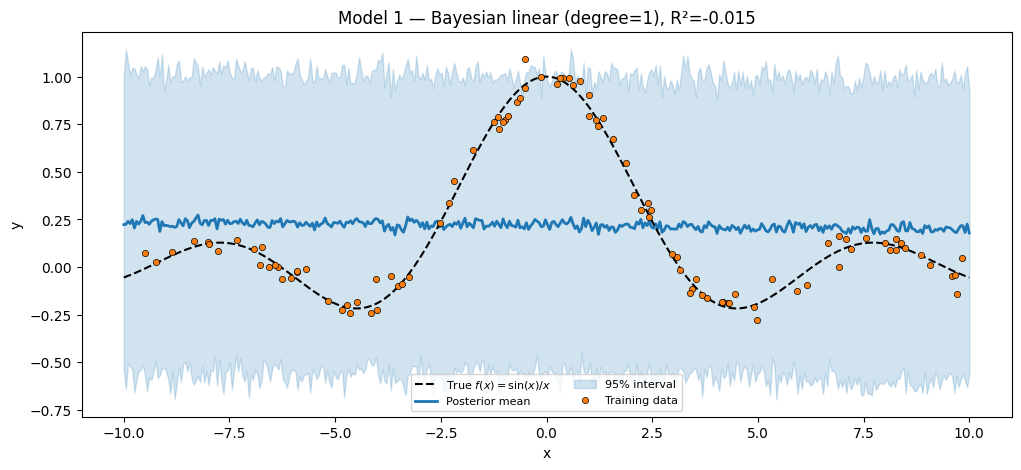

In [6]:
mcmc_linear = MCMC(
    NUTS(model_linear), num_warmup=300, num_samples=500, progress_bar=False
)
mcmc_linear.run(k_models[0], x_train, y_train, degree=1)
samples_linear = mcmc_linear.get_samples()

preds_linear = Predictive(model_linear, posterior_samples=samples_linear)(
    k_models[1], x_test, degree=1
)["obs"]
mean_linear = preds_linear.mean(0)
lo_linear, hi_linear = jnp.quantile(preds_linear, jnp.array([0.025, 0.975]), axis=0)
r2_linear = r2(y_test, mean_linear)

print(f"Bayesian linear (degree=1) R² = {r2_linear:.4f}")
assert r2_linear < 0.3, "Degree-1 polynomial should NOT fit sinc; R² should be near 0."

fig, ax = plt.subplots(figsize=(12, 5))
plot_fit(
    ax,
    x_train,
    y_train,
    x_test,
    y_test,
    mean_linear,
    lo_linear,
    hi_linear,
    title=f"Model 1 — Bayesian linear (degree=1), R²={r2_linear:.3f}",
)
plt.show()

## Model 2 — MLP via MAP

A single-hidden-layer MLP, fitted with MAP via SVI + `AutoDelta`. Maximizing the ELBO with a delta guide is exactly MAP estimation: $\arg\max_\theta \log p(\mathcal{D}, \theta)$. The result is a single point estimate — no uncertainty band.

**Generative model.**

$$W_1 \in \mathbb{R}^{1 \times H},\ b_1 \in \mathbb{R}^{H},\ W_2 \in \mathbb{R}^{H \times 1},\ b_2 \in \mathbb{R} \;\sim\; \mathcal{N}(0, 1)$$

$$h = \tanh(x W_1 + b_1), \qquad f(x) = h W_2 + b_2, \qquad y_i \sim \mathcal{N}(f(x_i), \sigma^2)$$

**The bridge.** Tuple selector `lambda m: (m.W1, m.b1, m.W2, m.b2)` replaces all four leaves at once. The two einsum patterns spell out the MLP's two contractions: `"n, one h -> n h"` broadcasts each scalar input across the hidden dimension; `"n h, h one -> n"` contracts the hidden dimension and collapses the singleton output dim.

In [7]:
class MLP(eqx.Module):
    W1: jax.Array
    b1: jax.Array
    W2: jax.Array
    b2: jax.Array
    hidden_dim: int = eqx.field(static=True)

    def __init__(self, hidden_dim: int, *, key):
        self.hidden_dim = hidden_dim
        k1, k2 = jr.split(key)
        self.W1 = 0.1 * jr.normal(k1, (1, hidden_dim))
        self.b1 = jnp.zeros(hidden_dim)
        self.W2 = 0.1 * jr.normal(k2, (hidden_dim, 1))
        self.b2 = jnp.array(0.0)

    def __call__(self, x):
        h = jnp.tanh(einsum(x, self.W1, "n, one h -> n h") + self.b1)
        return einsum(h, self.W2, "n h, h one -> n") + self.b2


def model_nnet(x, y=None, *, hidden_dim):
    net = MLP(hidden_dim=hidden_dim, key=jr.PRNGKey(0))
    W1 = numpyro.sample("W1", dist.Normal(jnp.zeros((1, hidden_dim)), 1.0))
    b1 = numpyro.sample("b1", dist.Normal(jnp.zeros(hidden_dim), 1.0))
    W2 = numpyro.sample("W2", dist.Normal(jnp.zeros((hidden_dim, 1)), 1.0))
    b2 = numpyro.sample("b2", dist.Normal(0.0, 1.0))
    net = eqx.tree_at(lambda m: (m.W1, m.b1, m.W2, m.b2), net, (W1, b1, W2, b2))
    f = numpyro.deterministic("f", net(x))
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))
    numpyro.sample("obs", dist.Normal(f, sigma), obs=y)

**MAP via SVI.** `AutoDelta` places a learnable point mass on every latent variable. The `SVI` loop optimizes those point locations to maximize the joint $\log p(y, \theta)$.

MAP MLP (H=30) R² = 0.9917


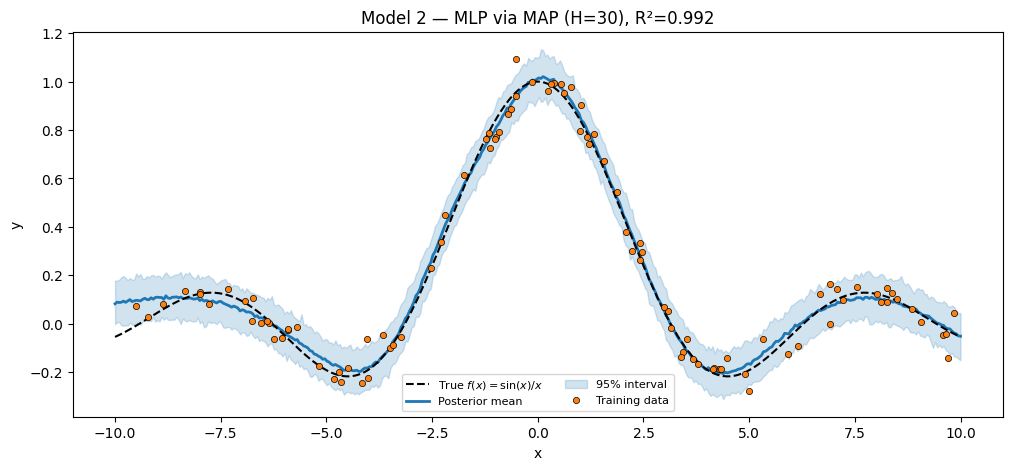

In [8]:
guide_nnet = AutoDelta(model_nnet)
svi_nnet = SVI(model_nnet, guide_nnet, Adam(5e-3), Trace_ELBO())
svi_result_nnet = svi_nnet.run(
    k_models[2], 2000, x_train, y_train, hidden_dim=30, progress_bar=False
)
preds_nnet = Predictive(
    model_nnet, params=svi_result_nnet.params, num_samples=200, guide=guide_nnet
)(k_models[3], x_test, hidden_dim=30)["obs"]
mean_nnet = preds_nnet.mean(0)
lo_nnet, hi_nnet = jnp.quantile(preds_nnet, jnp.array([0.025, 0.975]), axis=0)
r2_nnet = r2(y_test, mean_nnet)

print(f"MAP MLP (H=30) R² = {r2_nnet:.4f}")
assert r2_nnet > 0.85, f"MAP MLP should fit sinc well; got R²={r2_nnet:.3f}."

fig, ax = plt.subplots(figsize=(12, 5))
plot_fit(
    ax,
    x_train,
    y_train,
    x_test,
    y_test,
    mean_nnet,
    lo_nnet,
    hi_nnet,
    title=f"Model 2 — MLP via MAP (H=30), R²={r2_nnet:.3f}",
)
plt.show()

The "uncertainty band" here is just the observation noise propagated through `Predictive` — MAP returns a point estimate of the parameters, so all of the predictive uncertainty comes from $\sigma$, not from any spread over $\theta$.

## Model 3 — MC-Dropout MLP

Gal & Ghahramani (2016) reinterpret dropout as approximate Bayesian inference. The trick is to keep the random binary mask active at *both* train and predict time, then average predictions across mask draws to get a Monte-Carlo posterior-predictive distribution.

**Generative model.**

$$z_{ij} \sim \text{Bernoulli}(1 - p_{\text{drop}}), \qquad h_i = \tanh(x_i W_1 + b_1)$$

$$\tilde h_i = h_i \odot z_i / (1 - p_{\text{drop}}), \qquad f(x_i) = \tilde h_i W_2 + b_2, \qquad y_i \sim \mathcal{N}(f(x_i), \sigma^2)$$

The inverted-dropout rescaling by $1/(1 - p_{\text{drop}})$ keeps $\mathbb{E}[\tilde h] = h$, so no train-test rescaling is needed.

**PPL note — why the mask is *not* a `numpyro.sample` site.** Discrete latent variables in a model force the ELBO to enumerate them (handled by the optional `funsor` backend). For a binary mask of shape $(N, H)$ that's $2^{NH}$ configurations — totally unworkable. The clean alternative: treat the mask as a deterministic JAX op that consumes a per-call RNG via [`numpyro.prng_key()`](https://num.pyro.ai/en/stable/primitives.html#prng-key). Inside any `seed` / `SVI` / `Predictive` handler, `numpyro.prng_key()` returns a fresh key each call — so a new mask is drawn at every gradient step (the dropout regularization story) and at every predictive draw (the MC posterior-predictive story). Same Bayesian semantics, no enumeration, no extra dependency.

In [9]:
class MLPDropout(eqx.Module):
    W1: jax.Array
    b1: jax.Array
    W2: jax.Array
    b2: jax.Array
    hidden_dim: int = eqx.field(static=True)
    dropout_rate: float = eqx.field(static=True)

    def __init__(self, hidden_dim: int, dropout_rate: float, *, key):
        self.hidden_dim = hidden_dim
        self.dropout_rate = dropout_rate
        k1, k2 = jr.split(key)
        self.W1 = 0.1 * jr.normal(k1, (1, hidden_dim))
        self.b1 = jnp.zeros(hidden_dim)
        self.W2 = 0.1 * jr.normal(k2, (hidden_dim, 1))
        self.b2 = jnp.array(0.0)

    def __call__(self, x, mask):
        h = jnp.tanh(einsum(x, self.W1, "n, one h -> n h") + self.b1)
        h = h * mask / (1.0 - self.dropout_rate)
        return einsum(h, self.W2, "n h, h one -> n") + self.b2


def model_nnet_dropout(x, y=None, *, hidden_dim, dropout_rate):
    N = x.shape[0]
    # numpyro.prng_key() returns a fresh key at every model-trace, so the
    # mask varies per SVI step (training-time regularisation) and per
    # Predictive draw (test-time MC uncertainty) without any explicit loop.
    rng_key = numpyro.prng_key()
    mask = jr.bernoulli(rng_key, p=1.0 - dropout_rate, shape=(N, hidden_dim)).astype(
        jnp.float64
    )
    net = MLPDropout(
        hidden_dim=hidden_dim, dropout_rate=dropout_rate, key=jr.PRNGKey(0)
    )
    W1 = numpyro.sample("W1", dist.Normal(jnp.zeros((1, hidden_dim)), 1.0))
    b1 = numpyro.sample("b1", dist.Normal(jnp.zeros(hidden_dim), 1.0))
    W2 = numpyro.sample("W2", dist.Normal(jnp.zeros((hidden_dim, 1)), 1.0))
    b2 = numpyro.sample("b2", dist.Normal(0.0, 1.0))
    net = eqx.tree_at(lambda m: (m.W1, m.b1, m.W2, m.b2), net, (W1, b1, W2, b2))
    f = numpyro.deterministic("f", net(x, mask))
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))
    numpyro.sample("obs", dist.Normal(f, sigma), obs=y)

Train via MAP (`AutoDelta` + `Trace_ELBO`); predict via `Predictive`. Each predictive draw triggers a fresh model trace, which calls `numpyro.prng_key()`, which yields a fresh mask — so the 100 predictive samples below see 100 different masks against the same MAP-estimated weights. The spread across them *is* the MC-Dropout posterior-predictive uncertainty.

MC-Dropout MLP (H=30, p=0.1) R² = 0.9061


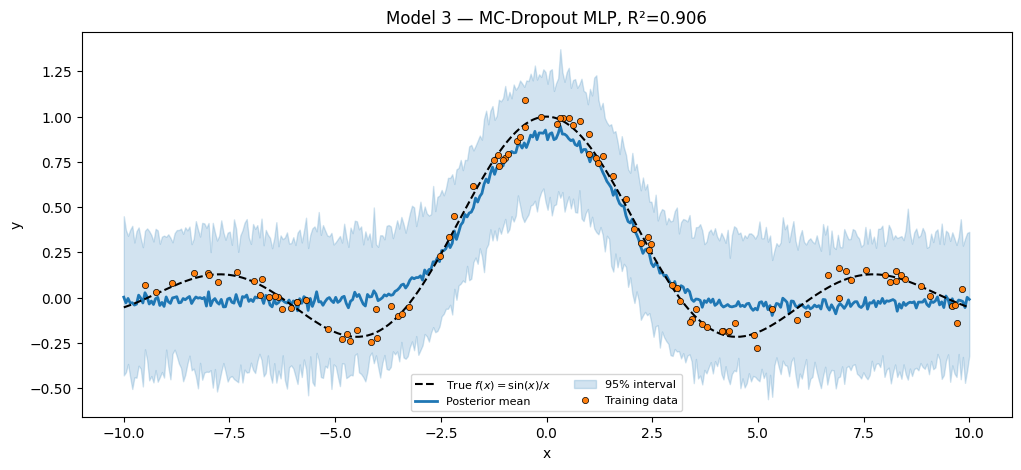

In [10]:
guide_dropout = AutoDelta(model_nnet_dropout)
svi_dropout = SVI(model_nnet_dropout, guide_dropout, Adam(5e-3), Trace_ELBO())
svi_result_dropout = svi_dropout.run(
    k_models[4],
    2000,
    x_train,
    y_train,
    hidden_dim=30,
    dropout_rate=0.1,
    progress_bar=False,
)
preds_dropout = Predictive(
    model_nnet_dropout,
    params=svi_result_dropout.params,
    num_samples=100,
    guide=guide_dropout,
)(k_models[5], x_test, hidden_dim=30, dropout_rate=0.1)["obs"]
mean_dropout = preds_dropout.mean(0)
lo_dropout, hi_dropout = jnp.quantile(preds_dropout, jnp.array([0.025, 0.975]), axis=0)
r2_dropout = r2(y_test, mean_dropout)

print(f"MC-Dropout MLP (H=30, p=0.1) R² = {r2_dropout:.4f}")
assert r2_dropout > 0.80, f"MC-Dropout should fit sinc; got R²={r2_dropout:.3f}."

fig, ax = plt.subplots(figsize=(12, 5))
plot_fit(
    ax,
    x_train,
    y_train,
    x_test,
    y_test,
    mean_dropout,
    lo_dropout,
    hi_dropout,
    title=f"Model 3 — MC-Dropout MLP, R²={r2_dropout:.3f}",
)
plt.show()

## Model 4 — Bayesian MLP via NUTS

Same `MLP` module as Model 2 — only the inference method changes. NUTS gives the *full* posterior over $(W_1, b_1, W_2, b_2, \sigma)$, not just a MAP point. Predictive draws now propagate parameter uncertainty in addition to observation noise.

**NUTS over neural network weights** is notoriously hard for large models, but with a small hidden dim (`H=15`) and 100 training points the geometry is mild enough to mix in a few seconds. The `MLP` module from Model 2 is reused as-is.

Bayesian MLP via NUTS (H=15) R² = 0.9945


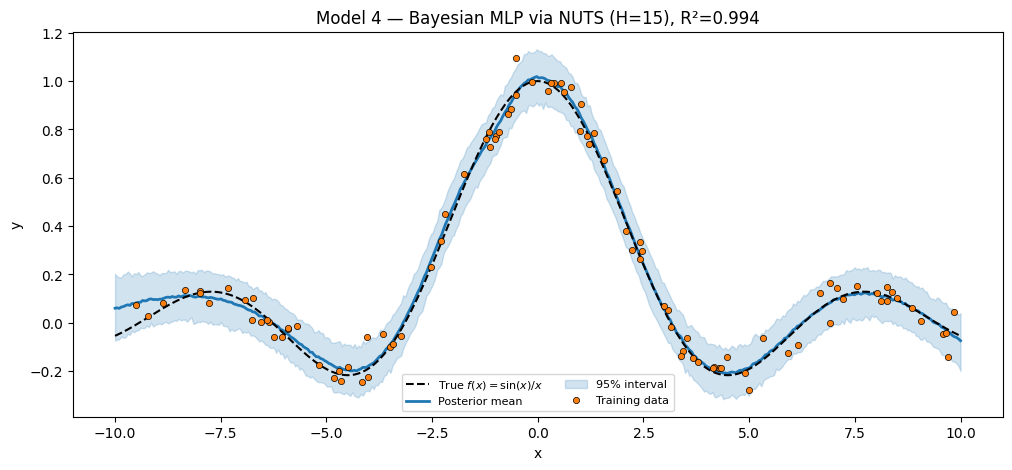

In [11]:
def model_bayesian_nnet(x, y=None, *, hidden_dim, prior_scale):
    net = MLP(hidden_dim=hidden_dim, key=jr.PRNGKey(0))
    W1 = numpyro.sample("W1", dist.Normal(jnp.zeros((1, hidden_dim)), prior_scale))
    b1 = numpyro.sample("b1", dist.Normal(jnp.zeros(hidden_dim), prior_scale))
    W2 = numpyro.sample("W2", dist.Normal(jnp.zeros((hidden_dim, 1)), prior_scale))
    b2 = numpyro.sample("b2", dist.Normal(0.0, prior_scale))
    net = eqx.tree_at(lambda m: (m.W1, m.b1, m.W2, m.b2), net, (W1, b1, W2, b2))
    f = numpyro.deterministic("f", net(x))
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))
    numpyro.sample("obs", dist.Normal(f, sigma), obs=y)


mcmc_bnnet = MCMC(
    NUTS(model_bayesian_nnet), num_warmup=300, num_samples=500, progress_bar=False
)
mcmc_bnnet.run(k_models[6], x_train, y_train, hidden_dim=15, prior_scale=1.0)
samples_bnnet = mcmc_bnnet.get_samples()

preds_bnnet = Predictive(model_bayesian_nnet, posterior_samples=samples_bnnet)(
    k_models[7], x_test, hidden_dim=15, prior_scale=1.0
)["obs"]
mean_bnnet = preds_bnnet.mean(0)
lo_bnnet, hi_bnnet = jnp.quantile(preds_bnnet, jnp.array([0.025, 0.975]), axis=0)
r2_bnnet = r2(y_test, mean_bnnet)

print(f"Bayesian MLP via NUTS (H=15) R² = {r2_bnnet:.4f}")
assert r2_bnnet > 0.70, f"Bayesian MLP via NUTS should fit sinc; got R²={r2_bnnet:.3f}."

fig, ax = plt.subplots(figsize=(12, 5))
plot_fit(
    ax,
    x_train,
    y_train,
    x_test,
    y_test,
    mean_bnnet,
    lo_bnnet,
    hi_bnnet,
    title=f"Model 4 — Bayesian MLP via NUTS (H=15), R²={r2_bnnet:.3f}",
)
plt.show()

## Model 5 — SVR via Random Fourier Features

Rahimi & Recht (2007) approximate any shift-invariant kernel by a finite-dimensional inner product. For the RBF kernel with lengthscale $\ell$:

$$\omega_j \sim \mathcal{N}(0, \ell^{-2}), \qquad b_j \sim \text{Uniform}(0, 2\pi), \qquad \phi(x)_j = \sqrt{2/D}\,\cos(\omega_j x + b_j)$$

gives $\phi(x)^\top \phi(x') \approx k_{\text{RBF}}(x, x')$. Bayesian inference over the linear weights $w \in \mathbb{R}^D$ is equivalent to GP regression with the approximate kernel — at $O(D^3)$ cost instead of $O(N^3)$.

**The bridge.** No `eqx.tree_at` here — the RFF module's frequencies are *fixed*, and only the linear weights $w$ are sampled. The forward pass is `einsum(rff(x), w, "n d, d -> n")`.

SVR via RFF (D=40) R² = 0.9957


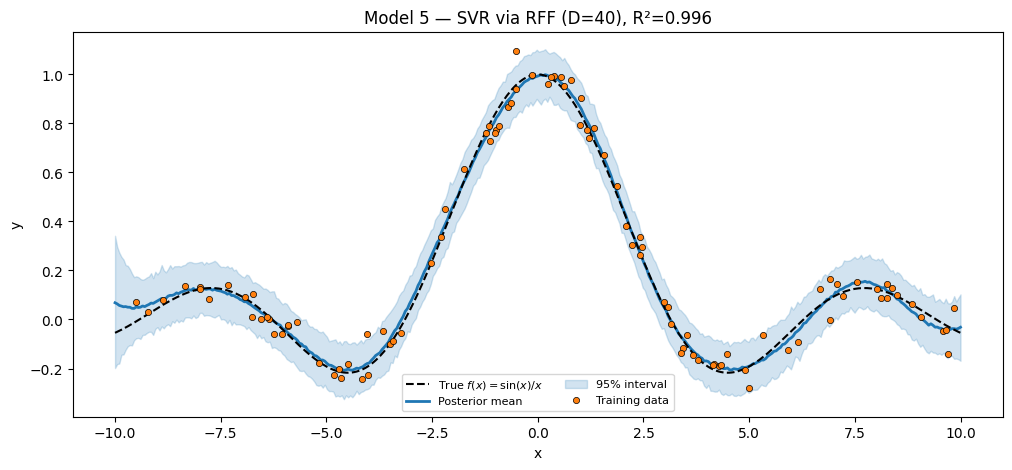

In [12]:
class RFFFeatureMap(eqx.Module):
    omega: jax.Array
    bias: jax.Array
    n_features: int = eqx.field(static=True)

    def __init__(self, n_features: int, lengthscale: float, *, key):
        self.n_features = n_features
        k1, k2 = jr.split(key)
        self.omega = jr.normal(k1, (n_features,)) / lengthscale
        self.bias = jr.uniform(k2, (n_features,), minval=0.0, maxval=2.0 * jnp.pi)

    def __call__(self, x):
        # einsum "n, d -> n d" is the outer product (no contraction).
        projection = einsum(x, self.omega, "n, d -> n d")
        return jnp.sqrt(2.0 / self.n_features) * jnp.cos(projection + self.bias)


def model_svr_rff(x, y=None, *, rff):
    D = rff.n_features
    Phi = rff(x)
    w = numpyro.sample("w", dist.Normal(jnp.zeros(D), 1.0))
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))
    f = numpyro.deterministic("f", einsum(Phi, w, "n d, d -> n"))
    numpyro.sample("obs", dist.Normal(f, sigma), obs=y)


rff_svr = RFFFeatureMap(n_features=40, lengthscale=1.0, key=k_models[8])
mcmc_svr = MCMC(
    NUTS(model_svr_rff), num_warmup=300, num_samples=500, progress_bar=False
)
mcmc_svr.run(k_models[9], x_train, y_train, rff=rff_svr)
samples_svr = mcmc_svr.get_samples()

preds_svr = Predictive(model_svr_rff, posterior_samples=samples_svr)(
    k_models[10], x_test, rff=rff_svr
)["obs"]
mean_svr = preds_svr.mean(0)
lo_svr, hi_svr = jnp.quantile(preds_svr, jnp.array([0.025, 0.975]), axis=0)
r2_svr = r2(y_test, mean_svr)

print(f"SVR via RFF (D=40) R² = {r2_svr:.4f}")
assert r2_svr > 0.80, f"SVR via RFF should fit sinc well; got R²={r2_svr:.3f}."

fig, ax = plt.subplots(figsize=(12, 5))
plot_fit(
    ax,
    x_train,
    y_train,
    x_test,
    y_test,
    mean_svr,
    lo_svr,
    hi_svr,
    title=f"Model 5 — SVR via RFF (D=40), R²={r2_svr:.3f}",
)
plt.show()

## Model 6 — Approximate GP via hierarchical RFF

Same `RFFFeatureMap` as Model 5, but with a hierarchical prior on the weight amplitude $\alpha$. Learning $\alpha$ approximates learning the GP signal-variance hyperparameter:

$$\alpha \sim \text{HalfNormal}(1), \qquad w \sim \mathcal{N}(0, \alpha^2 I_D), \qquad \sigma \sim \text{HalfNormal}(0.1)$$

The tighter $\sigma$ prior pushes more variance into the function (the signal) and less into noise — appropriate when we believe the data is mostly explained by the latent function.

Approx GP via hierarchical RFF (D=40) R² = 0.9962


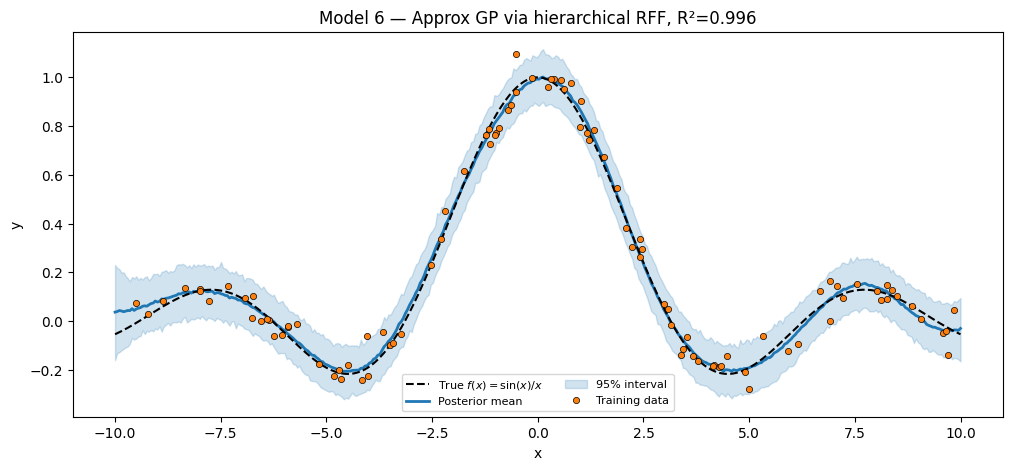

In [13]:
def model_gp_rff(x, y=None, *, rff):
    D = rff.n_features
    Phi = rff(x)
    amplitude = numpyro.sample("amplitude", dist.HalfNormal(1.0))
    w = numpyro.sample("w", dist.Normal(jnp.zeros(D), amplitude))
    sigma = numpyro.sample("sigma", dist.HalfNormal(0.1))
    f = numpyro.deterministic("f", einsum(Phi, w, "n d, d -> n"))
    numpyro.sample("obs", dist.Normal(f, sigma), obs=y)


mcmc_gp = MCMC(NUTS(model_gp_rff), num_warmup=300, num_samples=500, progress_bar=False)
mcmc_gp.run(k_models[11], x_train, y_train, rff=rff_svr)
samples_gp = mcmc_gp.get_samples()

preds_gp = Predictive(model_gp_rff, posterior_samples=samples_gp)(
    k_models[12], x_test, rff=rff_svr
)["obs"]
mean_gp = preds_gp.mean(0)
lo_gp, hi_gp = jnp.quantile(preds_gp, jnp.array([0.025, 0.975]), axis=0)
r2_gp = r2(y_test, mean_gp)

print(f"Approx GP via hierarchical RFF (D=40) R² = {r2_gp:.4f}")
assert r2_gp > 0.80, f"Approx-GP via RFF should fit sinc well; got R²={r2_gp:.3f}."

fig, ax = plt.subplots(figsize=(12, 5))
plot_fit(
    ax,
    x_train,
    y_train,
    x_test,
    y_test,
    mean_gp,
    lo_gp,
    hi_gp,
    title=f"Model 6 — Approx GP via hierarchical RFF, R²={r2_gp:.3f}",
)
plt.show()

## Model 7 — Deep GP via two-layer RFF

Cutajar et al. (2017) compose two RFF layers with a learned linear map between them, mimicking a two-layer Deep GP.

**Layer 1.** $\Phi_1(x) = \text{rff}_1(x) \in \mathbb{R}^{N \times D_1}$, $h = \Phi_1 W_1 \in \mathbb{R}^{N \times \text{inner}}$.

**Layer 2.** Apply $\text{rff}_2$ independently to each hidden dimension, average across hidden dims, then linearly project: $\Phi_2 = \tfrac{1}{\text{inner}}\sum_j \text{rff}_2(h_{:,j})$, $f = \Phi_2 w_2$.

**The bridge.** Tuple selector `lambda m: (m.W1, m.w2)` — only the *learnable* weights are replaced; both `rff1` and `rff2` modules pass through untouched, preserving their fixed random frequencies.

Deep GP via two-layer RFF (D1=15, D2=10, inner=4) R² = 0.9947


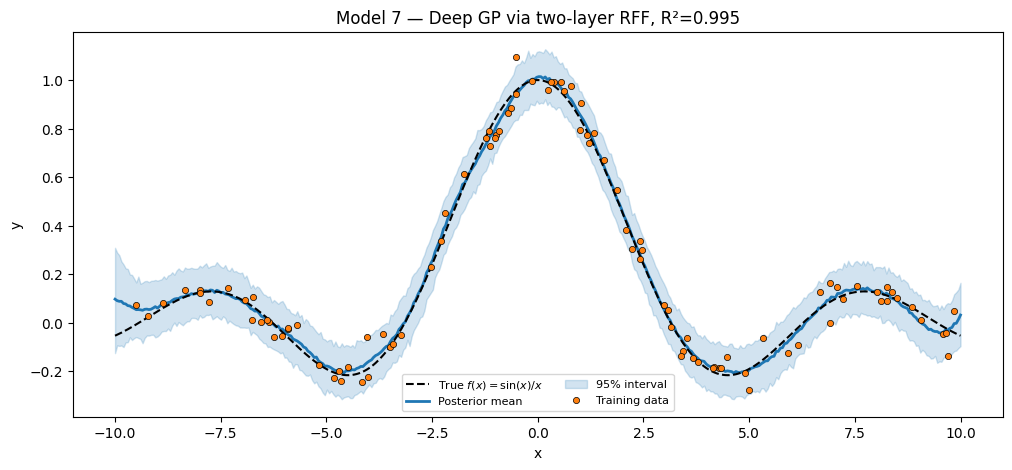

In [14]:
class DeepRFFRegressor(eqx.Module):
    rff1: RFFFeatureMap
    W1: jax.Array
    rff2: RFFFeatureMap
    w2: jax.Array
    inner_dim: int = eqx.field(static=True)

    def __init__(
        self,
        n_features_1,
        n_features_2,
        inner_dim,
        lengthscale_1=1.0,
        lengthscale_2=1.0,
        *,
        key,
    ):
        k1, k2, k3 = jr.split(key, 3)
        self.inner_dim = inner_dim
        self.rff1 = RFFFeatureMap(n_features_1, lengthscale_1, key=k1)
        self.W1 = 0.1 * jr.normal(k2, (n_features_1, inner_dim))
        self.rff2 = RFFFeatureMap(n_features_2, lengthscale_2, key=k3)
        self.w2 = jnp.zeros(n_features_2)

    def __call__(self, x):
        Phi1 = self.rff1(x)
        h = einsum(Phi1, self.W1, "n d1, d1 inner -> n inner")
        Phi2 = jnp.mean(
            jnp.stack([self.rff2(h[:, j]) for j in range(self.inner_dim)], axis=0),
            axis=0,
        )
        return einsum(Phi2, self.w2, "n d2, d2 -> n")


def model_deep_gp_rff(x, y=None, *, deep_rff):
    D1 = deep_rff.rff1.n_features
    D2 = deep_rff.rff2.n_features
    inner = deep_rff.inner_dim
    W1 = numpyro.sample("W1", dist.Normal(jnp.zeros((D1, inner)), 1.0))
    w2 = numpyro.sample("w2", dist.Normal(jnp.zeros(D2), 1.0))
    mod = eqx.tree_at(lambda m: (m.W1, m.w2), deep_rff, (W1, w2))
    f = numpyro.deterministic("f", mod(x))
    sigma = numpyro.sample("sigma", dist.HalfNormal(0.1))
    numpyro.sample("obs", dist.Normal(f, sigma), obs=y)


deep_rff = DeepRFFRegressor(
    n_features_1=15, n_features_2=10, inner_dim=4, key=k_models[13]
)
mcmc_deep = MCMC(
    NUTS(model_deep_gp_rff), num_warmup=200, num_samples=300, progress_bar=False
)
mcmc_deep.run(k_models[14], x_train, y_train, deep_rff=deep_rff)
samples_deep = mcmc_deep.get_samples()

preds_deep = Predictive(model_deep_gp_rff, posterior_samples=samples_deep)(
    k_models[14], x_test, deep_rff=deep_rff
)["obs"]
mean_deep = preds_deep.mean(0)
lo_deep, hi_deep = jnp.quantile(preds_deep, jnp.array([0.025, 0.975]), axis=0)
r2_deep = r2(y_test, mean_deep)

print(f"Deep GP via two-layer RFF (D1=15, D2=10, inner=4) R² = {r2_deep:.4f}")
assert r2_deep > 0.70, f"Deep RFF should fit sinc; got R²={r2_deep:.3f}."

fig, ax = plt.subplots(figsize=(12, 5))
plot_fit(
    ax,
    x_train,
    y_train,
    x_test,
    y_test,
    mean_deep,
    lo_deep,
    hi_deep,
    title=f"Model 7 — Deep GP via two-layer RFF, R²={r2_deep:.3f}",
)
plt.show()

## Side-by-side summary

All seven models, scored on the same held-out grid. The 1×3 panel below stacks three representative posteriors so you can compare the qualitative shape of the predictive bands.

Model                                    Inference         R²
------------------------------------------------------------
1. Bayesian linear (degree=1)            NUTS          -0.015
2. MLP via MAP                           SVI+Delta      0.992
3. MC-Dropout MLP                        SVI+Delta      0.906
4. Bayesian MLP                          NUTS           0.994
5. SVR via RFF (D=40)                    NUTS           0.996
6. Approx GP via hierarchical RFF        NUTS           0.996
7. Deep GP via two-layer RFF             NUTS           0.995


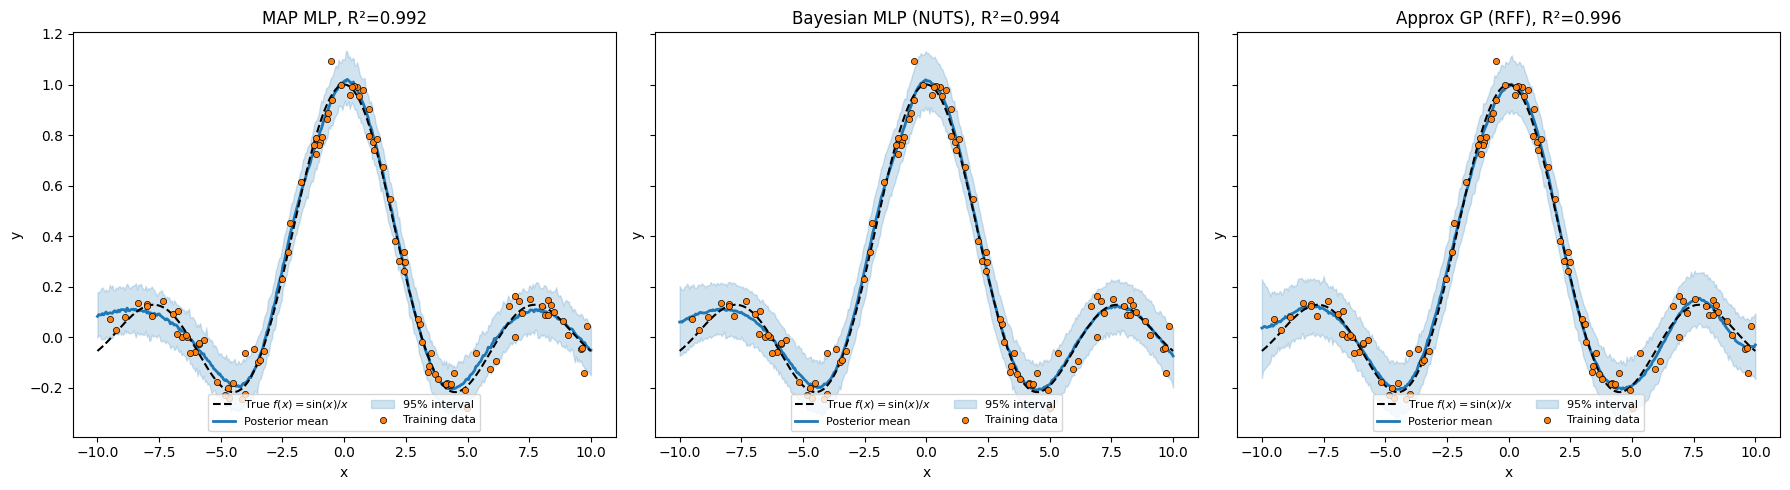

In [15]:
print(f"{'Model':<40} {'Inference':<12} {'R²':>7}")
print("-" * 60)
print(f"{'1. Bayesian linear (degree=1)':<40} {'NUTS':<12} {r2_linear:>7.3f}")
print(f"{'2. MLP via MAP':<40} {'SVI+Delta':<12} {r2_nnet:>7.3f}")
print(f"{'3. MC-Dropout MLP':<40} {'SVI+Delta':<12} {r2_dropout:>7.3f}")
print(f"{'4. Bayesian MLP':<40} {'NUTS':<12} {r2_bnnet:>7.3f}")
print(f"{'5. SVR via RFF (D=40)':<40} {'NUTS':<12} {r2_svr:>7.3f}")
print(f"{'6. Approx GP via hierarchical RFF':<40} {'NUTS':<12} {r2_gp:>7.3f}")
print(f"{'7. Deep GP via two-layer RFF':<40} {'NUTS':<12} {r2_deep:>7.3f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
plot_fit(
    axes[0],
    x_train,
    y_train,
    x_test,
    y_test,
    mean_nnet,
    lo_nnet,
    hi_nnet,
    title=f"MAP MLP, R²={r2_nnet:.3f}",
)
plot_fit(
    axes[1],
    x_train,
    y_train,
    x_test,
    y_test,
    mean_bnnet,
    lo_bnnet,
    hi_bnnet,
    title=f"Bayesian MLP (NUTS), R²={r2_bnnet:.3f}",
)
plot_fit(
    axes[2],
    x_train,
    y_train,
    x_test,
    y_test,
    mean_gp,
    lo_gp,
    hi_gp,
    title=f"Approx GP (RFF), R²={r2_gp:.3f}",
)
plt.tight_layout()
plt.show()

## What's next

This notebook is the **raw recipe** — every prior is a `numpyro.sample` call in the model function and every weight injection is an explicit `eqx.tree_at`. The two sibling notebooks show what the same seven models look like when you let `pyrox` carry more of the boilerplate:

- **Pattern 2 — `PyroxModule` + `pyrox_sample`.** Layers self-register their priors during `__call__`. The model function shrinks to `f = net(x); numpyro.sample("obs", ..., obs=y)`. Every layer in [`pyrox.nn._layers`](https://github.com/jejjohnson/pyrox/blob/main/src/pyrox/nn/_layers.py) follows this pattern; this notebook will let you read those layers fluently.
- **Pattern 3 — `Parameterized` + `PyroxParam`.** Constraints, priors, and autoguide selection become declarative class fields registered in `setup()`. `pyrox.gp` kernels (`RBF`, `Matern`, …) all use this pattern in production, and Models 6–7 swap their RFF approximations for actual `pyrox.gp.GPPrior` + `ConditionedGP` end-to-end.

The same seven models, three abstraction levels — pick the one that fits your problem.